## 2. Testes de convergência de séries

> **Nota de reorganização (rascunho estrutural):** este notebook foi remontado a partir do material do notebook antigo correspondente (pasta `Notebooks_v1_arquivo/`) como parte da reestruturação do curso em 14 notebooks. O conteúdo ainda passará por um ajuste fino (revisão de texto, remoção de redundâncias, exercícios) em uma etapa posterior.

Neste notebook vamos explorar, por meio de **experimentos computacionais**, alguns critérios usados para decidir se uma série converge ou diverge: o teste da comparação, o teste da integral, o teste da razão e o teste da raiz. O objetivo aqui não é a demonstração formal de cada teste, mas desenvolver intuição observando o comportamento numérico das séries. Ao final, veremos como o `SymPy` pode auxiliar nesse tipo de análise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

### 2.1 Teste da comparação

*Ideia:* se $0 \le a_n \le b_n$ para todo $n$ suficientemente grande e $\sum b_n$ converge, então $\sum a_n$ também converge. Se $\sum a_n$ diverge, então $\sum b_n$ também diverge.

**Exemplo:** vamos comparar $a_n = \dfrac{1}{n^2+n}$ com a p-série conhecida $b_n = \dfrac{1}{n^2}$.

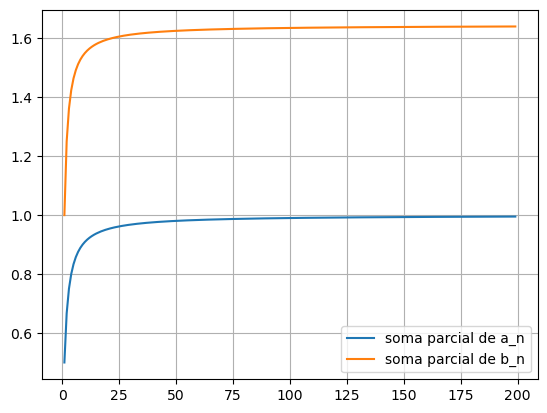

soma parcial de a_n (n=200): 0.9949999999999993
soma parcial de b_n (n=200): 1.6399215460149972


In [2]:
n = np.arange(1, 200)
a = 1/(n**2+n)
b = 1/(n**2)

plt.plot(n, np.cumsum(a), label='soma parcial de a_n')
plt.plot(n, np.cumsum(b), label='soma parcial de b_n')
plt.legend(); plt.grid(); plt.show()

print('soma parcial de a_n (n=200):', np.cumsum(a)[-1])
print('soma parcial de b_n (n=200):', np.cumsum(b)[-1])

**Atividade 2.1:** Escolha outras duas séries (uma conhecida e uma nova) e use o teste da comparação para investigar a convergência da série nova, seguindo o exemplo acima.

### 2.2 Teste da integral

*Ideia:* se $f$ é uma função positiva, contínua e decrescente para $x\ge N$ e $a_n=f(n)$, então $\sum a_n$ converge se, e somente se, $\int_N^\infty f(x)\,dx$ converge.

**Exemplo:** vamos comparar visualmente a série harmônica $a_n=1/n$ com a integral $\int_1^\infty \frac{1}{x}\,dx$.

In [3]:
x = sp.symbols('x', positive=True)
integral = sp.integrate(1/x, (x, 1, sp.oo))
display(integral)

oo

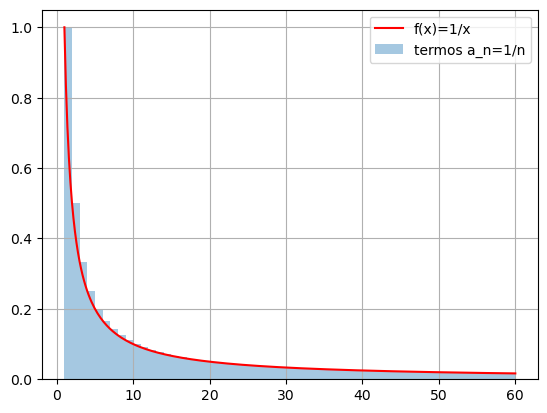

In [4]:
n = np.arange(1, 60)
plt.bar(n, 1/n, width=1.0, align='edge', alpha=0.4, label='termos a_n=1/n')
xx = np.linspace(1, 60, 300)
plt.plot(xx, 1/xx, 'r', label='f(x)=1/x')
plt.legend(); plt.grid(); plt.show()

**Atividade 2.2:** Repita a comparação gráfica acima para $a_n=\dfrac{1}{n\ln(n)^2}$ (comece em $n=2$) e use `sympy` para calcular a integral imprópria correspondente.

### 2.3 Teste da razão

*Ideia:* calculamos $L=\lim\limits_{n\to\infty}\left|\dfrac{a_{n+1}}{a_n}\right|$. Se $L<1$ a série converge (absolutamente); se $L>1$ a série diverge; se $L=1$ o teste é inconclusivo.

**Exemplo:** vamos investigar numericamente $a_n = \dfrac{2^n}{n!}$.

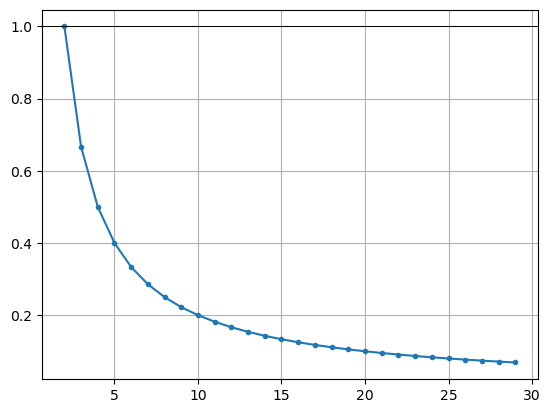

razao a_(n+1)/a_n para os ultimos termos: [0.08 0.07692307692307691 0.07407407407407408 0.07142857142857142
 0.06896551724137932]


In [5]:
import math
n = np.arange(1, 30)
a = 2.0**n/np.array([math.factorial(int(k)) for k in n])
razao = a[1:]/a[:-1]

plt.plot(n[1:], razao, '.-')
plt.axhline(1, color='k', lw=0.7)
plt.grid(); plt.show()
print('razao a_(n+1)/a_n para os ultimos termos:', razao[-5:])

Também podemos calcular o limite simbolicamente com `sympy`:

In [6]:
n = sp.symbols('n', positive=True, integer=True)
a = 2**n/sp.factorial(n)
L = sp.limit(a.subs(n, n+1)/a, n, sp.oo)
display(L)

0

**Atividade 2.3:** Use o teste da razão (numérico e simbólico) para investigar a convergência de $a_n = \dfrac{n!}{n^n}$.

### 2.4 Teste da raiz

*Ideia:* calculamos $L=\lim\limits_{n\to\infty}\sqrt[n]{|a_n|}$. Os critérios de convergência/divergência são os mesmos do teste da razão.

**Exemplo:** vamos investigar numericamente $a_n = \left(\dfrac{n}{n+1}\right)^{n^2}$.

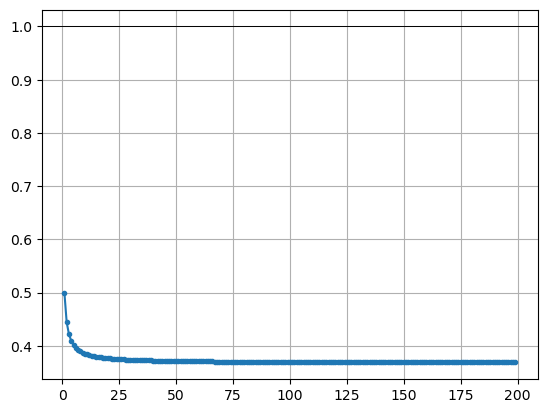

raiz n-esima para os ultimos termos: [0.36882071 0.36881592 0.36881118 0.36880648 0.36880183]


In [7]:
n = np.arange(1, 200)
a = (n/(n+1))**(n**2.0)
raiz = a**(1/n)

plt.plot(n, raiz, '.-')
plt.axhline(1, color='k', lw=0.7)
plt.grid(); plt.show()
print('raiz n-esima para os ultimos termos:', raiz[-5:])

**Atividade 2.4:** Use o teste da raiz para investigar a convergência de $a_n = \left(\dfrac{2n+1}{3n}\right)^n$, numérica e simbolicamente.

### 2.5 Usando SymPy para tratar séries

O `sympy` permite somar séries simbolicamente com `sp.Sum(...).doit()`, decompor termos gerais em frações parciais com `sp.apart`, e calcular limites com `sp.limit`, ferramentas úteis para confirmar (ou refutar) as conclusões dos experimentos numéricos acima.

In [8]:
n = sp.symbols('n', positive=True, integer=True)
soma = sp.Sum(1/(n*(n+1)), (n, 1, sp.oo))
display(soma, soma.doit())

Sum(1/(n*(n + 1)), (n, 1, oo))

1

**Atividade 2.5:** Escolha uma das séries investigadas anteriormente e confirme sua convergência (ou obtenha sua soma, se possível) usando `sympy`.